In [36]:
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain_tavily import TavilySearch
import os
from langchain.messages import HumanMessage,AIMessage
from scripts.base_tools import get_weather,get_seating_avalability


In [11]:
load_dotenv()

True

In [12]:
tavily_search=TavilySearch(max_results=2)

In [13]:
llm=ChatOllama(model="qwen3:30b",temperature=0)

In [14]:
system_prompt="""You are an expert tech financial analyst provide accurate results for stock prices"""

In [15]:
agent=create_agent(model=llm,tools=[tavily_search,get_weather,get_seating_avalability],system_prompt=system_prompt)

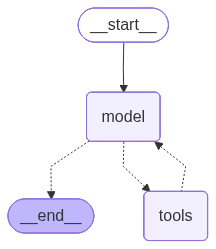

In [16]:
agent

In [17]:
response=agent.invoke({"messages":["What is the apple's current stock price"]})

In [18]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The current stock price for Apple Inc. (AAPL) is **$300.23** (latest close price as of the most recent trading session, based on Yahoo Finance data). 

*Note: Stock prices fluctuate throughout the trading day; this reflects the closing price for the latest completed trading session.*


In [19]:
response=agent.invoke({"messages":[HumanMessage(content="What is the current weather in chennai?")]})

In [20]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The current weather in Chennai is **38°C** with **Sunny** conditions.


In [21]:
for msg in response['messages']:
   if isinstance(msg,AIMessage):
      for tool in msg.tool_calls:
         print(tool['name'])
         print(tool['args'])

get_weather
{'location': 'Chennai'}


In [22]:
response

{'messages': [HumanMessage(content='What is the current weather in chennai?', additional_kwargs={}, response_metadata={}, id='cc5fcee2-7217-4755-8ddf-2fe1bba22961'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:30b', 'created_at': '2026-05-17T15:13:56.5560369Z', 'done': True, 'done_reason': 'stop', 'total_duration': 13920092700, 'load_duration': 145674400, 'prompt_eval_count': 1617, 'prompt_eval_duration': 886340100, 'eval_count': 108, 'eval_duration': 12868519000, 'logprobs': None, 'model_name': 'qwen3:30b', 'model_provider': 'ollama'}, id='lc_run--019e3680-0eea-7072-a75a-997aa055af64-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Chennai'}, 'id': '1538419a-8fb9-4c86-b2f2-a369b8893f16', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1617, 'output_tokens': 108, 'total_tokens': 1725}),
  ToolMessage(content='38 deg celcius,Sunny', name='get_weather', id='f85f50b5-48cb-4fe3-9e00-c1d00647249f', tool_call_id=

### 2. Short term memory with SQLite saver

In [23]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

conn=sqlite3.connect("data/financial_agent.db",check_same_thread=False)
checkpointer=SqliteSaver(conn=conn)


In [25]:
agent_memory=create_agent(model=llm,tools=[tavily_search,get_weather,get_seating_avalability],system_prompt=system_prompt,checkpointer=checkpointer)

In [27]:
response=agent_memory.invoke({"messages":[HumanMessage(content="What is the apple's current Stock price")]},config={"configurable":{"thread_id":"memory_session"}})

In [28]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The current stock price for Apple (AAPL) is **$300.23** as of the latest close, according to Yahoo Finance. This data is based on the most recent trading session. 

*Note: The WSJ result showing "$1.88" appears to be an error or misrepresentation, as Apple's stock price is consistently in the hundreds (not single digits) for recent trading.*


In [30]:
config={'configurable':{"thread_id":"memory_session"}}

In [31]:
response=agent_memory.invoke({"messages":[HumanMessage(content="What is the latest us stock news")]},config=config)

In [32]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The latest US stock news results from the search show two articles, though both contain **inconsistent future dates** (e.g., "May 2026" and "May 16, 2026"), which appear to be errors in the source data. Here's a summary:

1. **Yahoo Finance** highlights "Top 2 Consumer Staples Stocks for May 2026," noting expected sales growth of 2%–4% and earnings-per-share growth of 4%–6% for the year.  
2. **ACCESS Newswire** discusses "Penny Stock Lovers" amid "U.S. stock markets soaring to historic all-time highs" (dated May 16, 2026).

*Note: The future-dated references suggest potential data inaccuracies. For real-time updates, verify via a financial news platform like Bloomberg or Reuters.*


In [33]:
for msg in response['messages']:
    if isinstance(msg,AIMessage):
        for tool_call in msg.tool_calls:
            print(tool_call['name'])

tavily_search
tavily_search


In [34]:
for res in response['messages']:
    if isinstance(res,AIMessage):
        print(res.usage_metadata)

{'input_tokens': 1616, 'output_tokens': 370, 'total_tokens': 1986}
{'input_tokens': 2077, 'output_tokens': 420, 'total_tokens': 2497}
{'input_tokens': 2179, 'output_tokens': 830, 'total_tokens': 3009}
{'input_tokens': 2545, 'output_tokens': 683, 'total_tokens': 3228}


In [35]:
from langchain.agents.middleware import SummarizationMiddleware

In [41]:
agent_summary=create_agent(model=llm,tools=[tavily_search,get_weather,get_seating_avalability],checkpointer=checkpointer,
middleware=[
    SummarizationMiddleware(
        model=llm,
        trigger=[("messages", 15)],
            keep=("messages", 5)
    )
])

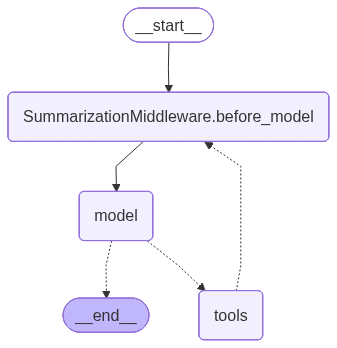

In [42]:
agent_summary

In [ ]:
response_summary=agent_summary.invoke({"messages":["What is current price of apple and microsoft.What is the leatest weather in chennai.What is latest news on asian stock market"]},config=config)

In [45]:
for msg in response['messages']:
    if isinstance(msg,AIMessage):
        for tool_call in msg.tool_calls:
            print(tool_call['name'])

tavily_search
tavily_search
tavily_search
get_weather
tavily_search


In [46]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

Here's the consolidated update for your queries:

---

### **1. Current Stock Prices**  
- **Apple (AAPL)**: **$300.23** (latest close, per Yahoo Finance).  
- **Microsoft (MSFT)**: **$393.18** (current price, based on Yahoo Finance data).  

*Note: Prices reflect recent trading sessions; verify via real-time platforms for live updates.*

---

### **2. Weather in Chennai**  
- **Temperature**: **38°C**  
- **Conditions**: **Sunny**  

---

### **3. Latest Asian Stock Market News**  
- **Nanya Technology (2408.TW)**: Highlighted as a potential undervalued stock in Asian markets, with analysis suggesting it may be trading below intrinsic value (source: Yahoo Finance, dated "May 2026" — likely a data error).  
- **Market Outlook**: A prediction for **May 21** (likely a typo for *today* or *recent date*) suggests Nvidia’s earnings report could impact global markets, though this focuses on U.S. equities (Nvidi

In [47]:
response['messages'][0].pretty_print()

================================ Human Message =================================

What is the apple's current Stock price
